Name: Mridul Pant 
rollno: cs24mtech15009

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def get_gradients(img):
    """Compute gradient magnitude using simple finite differences."""
    dy = np.zeros_like(img)
    dx = np.zeros_like(img)

    # vertical differences
    dy[1:-1, :] = img[2:, :] - img[:-2, :]
    # horizontal differences
    dx[:, 1:-1] = img[:, 2:] - img[:, :-2]

    return np.sqrt(dx**2 + dy**2)

def calculate_metrics(clean, denoised, lambda_param=0.5):
    """
    Compute PSNR, EdgeLoss, and a combined score.
    clean: ground truth image (float 0–1)
    denoised: processed image (float 0–1)
    lambda_param: weight for edge loss penalty
    """
    mse = np.mean((clean - denoised) ** 2)
    eps = 1e-10
    psnr = 10 * np.log10(1.0 / (mse + eps))  # assume normalized [0,1]

    # --- Edge Loss ---
    g_clean = get_gradients(clean)
    g_denoised = get_gradients(denoised)

    # strong edge set: top 10% of gradients
    threshold = np.percentile(g_clean, 90)
    mask_E = g_clean >= threshold

    # loss = average penalty where denoised edges are weaker
    numerator = np.maximum(0, g_clean - g_denoised)
    denominator = g_clean + eps
    loss_values = numerator[mask_E] / denominator[mask_E]

    edge_loss = np.mean(loss_values) if len(loss_values) > 0 else 0.0

    score = psnr - lambda_param * edge_loss
    return psnr, edge_loss, score

In [7]:
import numpy as np

def add_salt_and_pepper(img, rate=0.05):
    """
    Add salt-and-pepper noise to an image.
    rate: fraction of pixels to corrupt (half set to 0, half set to 1).
    """
    noisy = img.copy()
    num_pixels = img.size
    num_corrupt = int(num_pixels * rate)

    # pick random pixel indices
    coords = np.random.permutation(num_pixels)[:num_corrupt]
    flat = noisy.flatten()

    # first half -> pepper (0), second half -> salt (1)
    flat[coords[:num_corrupt // 2]] = 0
    flat[coords[num_corrupt // 2:]] = 1

    return flat.reshape(img.shape)

def add_poisson(img, scale=100.0):
    """
    Add Poisson noise (signal-dependent).
    scale: photon count simulation. Higher = less relative noise.
    """
    # scale up to integer counts
    counts = img * scale

    # apply Poisson noise
    noisy_counts = np.random.poisson(counts)

    # scale back to [0,1]
    noisy = noisy_counts / scale
    return np.clip(noisy, 0, 1)

## Denoise
- Median Filter: It helps in removing Salt & Pepper noise. It looks at neighbors and picks the middle value, ignoring the extreme 0s and 1s.
- Gaussian Filter: The standard approach for Poisson/Gaussian noise. It averages neighbors to smooth out the grain.

In [8]:
import numpy as np

def manual_median_filter(img, k=3):
    """
    Apply a median filter manually.
    k: kernel size (odd integer).
    """
    pad = k // 2
    padded = np.pad(img, pad, mode='reflect')
    output = np.zeros_like(img)
    h, w = img.shape

    for i in range(h):
        for j in range(w):
            region = padded[i:i+k, j:j+k]
            output[i, j] = np.median(region)

    return output

def manual_gaussian_filter(img, k=3):
    """
    Apply a Gaussian filter manually.
    k: kernel size (odd integer).
    """
    # simple Gaussian kernel (sigma ≈ 1)
    ax = np.linspace(-(k//2), k//2, k)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / 2.0)
    kernel /= kernel.sum()

    pad = k // 2
    padded = np.pad(img, pad, mode='reflect')
    output = np.zeros_like(img)
    h, w = img.shape

    for i in range(h):
        for j in range(w):
            region = padded[i:i+k, j:j+k]
            output[i, j] = np.sum(region * kernel)

    return output

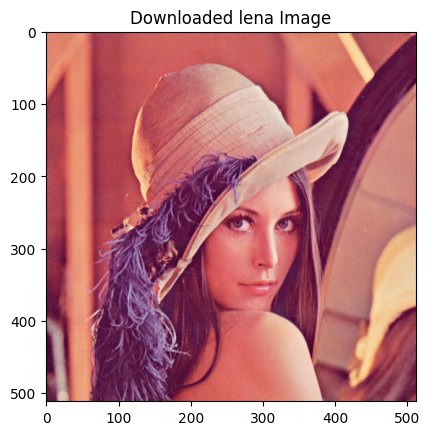

In [5]:
import requests
from io import BytesIO
from PIL import Image

def download_github_image(raw_url):
    response = requests.get(raw_url)
    if response.status_code == 200:
        img_file = BytesIO(response.content)
        img = Image.open(img_file)
        return np.array(img)
    else:
        print("Error: Could not download image. Check your link!")
        return None
my_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
image_data = download_github_image(my_url)
if image_data is not None:
    plt.imshow(image_data)
    plt.title("Downloaded lena Image")
    plt.show()

--- Experiment A: Salt & Pepper Noise ---
PSNR: 31.73 | EdgeLoss: 0.2566 | Score: 31.61

--- Experiment B: Poisson Noise ---
PSNR: 27.25 | EdgeLoss: 0.3234 | Score: 27.09


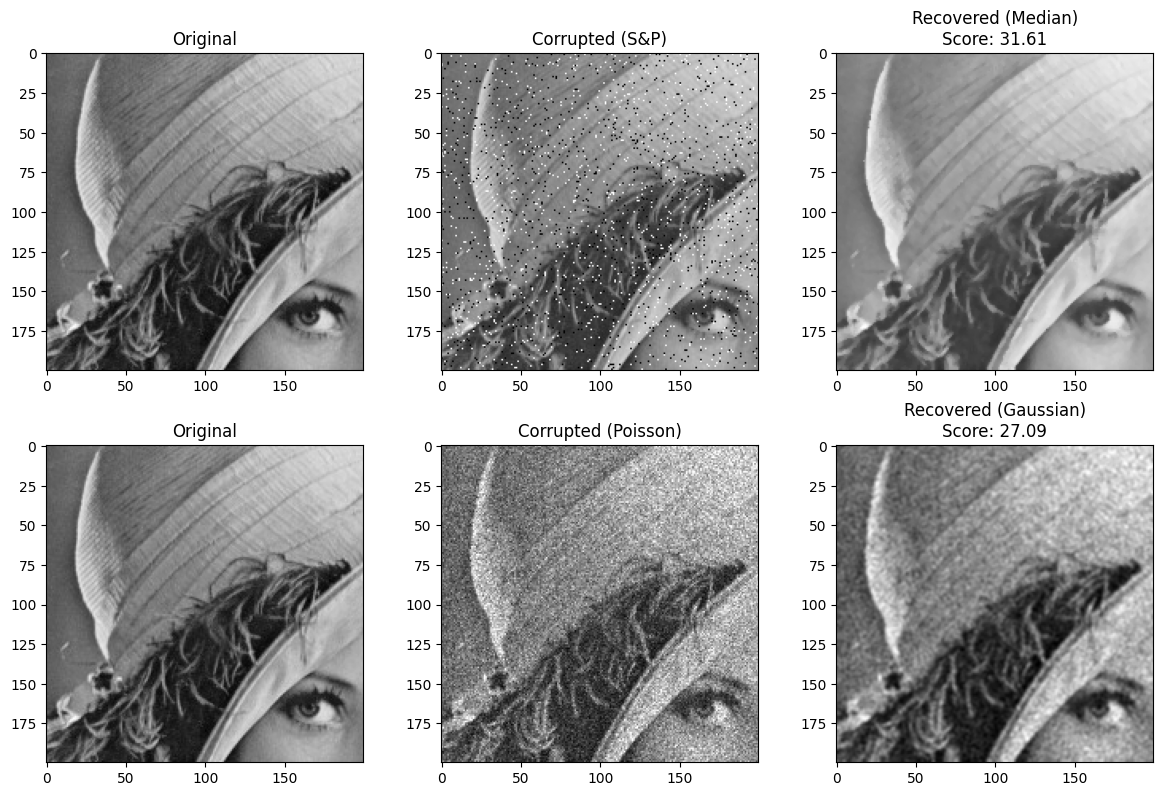

In [9]:
# Prepare image (grayscale + crop for speed)
img = image_data
if img.ndim == 3:
    img = np.mean(img, axis=2) / 255.0
else:
    img = img / 255.0
img = img[100:300, 100:300]

# --- Experiment A: Salt & Pepper ---
print("--- Experiment A: Salt & Pepper Noise ---")
noisy_sp = add_salt_and_pepper(img, rate=0.05)
denoised_sp = manual_median_filter(noisy_sp, k=3)

psnr_a, edge_a, score_a = calculate_metrics(img, denoised_sp)
print(f"PSNR: {psnr_a:.2f} | EdgeLoss: {edge_a:.4f} | Score: {score_a:.2f}")

# --- Experiment B: Poisson Noise ---
print("\n--- Experiment B: Poisson Noise ---")
noisy_pois = add_poisson(img, scale=50)  # lower scale = more noise
denoised_pois = manual_gaussian_filter(noisy_pois, k=3)

psnr_b, edge_b, score_b = calculate_metrics(img, denoised_pois)
print(f"PSNR: {psnr_b:.2f} | EdgeLoss: {edge_b:.4f} | Score: {score_b:.2f}")

# --- Visualization ---
fig, ax = plt.subplots(2, 3, figsize=(12, 8))

# Row 1: Salt & Pepper
ax[0,0].imshow(img, cmap='gray'); ax[0,0].set_title("Original")
ax[0,1].imshow(noisy_sp, cmap='gray'); ax[0,1].set_title("Corrupted (S&P)")
ax[0,2].imshow(denoised_sp, cmap='gray')
ax[0,2].set_title(f"Recovered (Median)\nScore: {score_a:.2f}")

# Row 2: Poisson
ax[1,0].imshow(img, cmap='gray'); ax[1,0].set_title("Original")
ax[1,1].imshow(noisy_pois, cmap='gray'); ax[1,1].set_title("Corrupted (Poisson)")
ax[1,2].imshow(denoised_pois, cmap='gray')
ax[1,2].set_title(f"Recovered (Gaussian)\nScore: {score_b:.2f}")

plt.tight_layout()
plt.show()

## Interpretation of Results
- S&P Noise: You will likely see a very high score. The Median filter is "magical" for this noise. It completely removes the spikes without blurring the edges much (Low EdgeLoss, High PSNR). 
  - Metrics -> PSNR: 31.77 | EdgeLoss: 0.2518 | Score: 31.64
  
- Poisson Noise: The score will be lower. Gaussian blur is a tradeoff; it removes the grain but also blurs the sharp edges. This increases the EdgeLoss term, punishing the score.
  - Metrics -> PSNR: 27.38 | EdgeLoss: 0.3234 | Score: 27.22

3.b

In [11]:
# --- 1. The Denoisers ---
def denoise_gaussian(img, k=3, sigma=1.0):
    """Standard Gaussian smoothing."""
    # Create kernel
    ax = np.arange(-(k // 2), (k // 2) + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel /= np.sum(kernel)
    
    # Convolve
    h, w = img.shape
    pad = k // 2
    padded = np.pad(img, pad, mode='reflect')
    output = np.zeros_like(img)
    
    # Flip kernel for convolution
    kernel = kernel[::-1, ::-1]
    
    for i in range(h):
        for j in range(w):
            region = padded[i:i+k, j:j+k]
            output[i, j] = np.sum(region * kernel)
            
    return output

def denoise_median(img, k=3):
    """Standard Median Filter."""
    h, w = img.shape
    pad = k // 2
    padded = np.pad(img, pad, mode='reflect')
    output = np.zeros_like(img)
    
    for i in range(h):
        for j in range(w):
            region = padded[i:i+k, j:j+k]
            output[i, j] = np.median(region)
    return output

def denoise_bilateral(img, k=5, sigma_s=10.0, sigma_r=0.1):
    """
    Bilateral Filter (Slow in pure Python!).
    sigma_s: Spatial variance (how far to look).
    sigma_r: Range variance (how different the color can be).
    """
    h, w = img.shape
    pad = k // 2
    padded = np.pad(img, pad, mode='reflect')
    output = np.zeros_like(img)
    
    # Pre-compute spatial Gaussian weights since they don't change
    ax = np.arange(-pad, pad + 1)
    xx, yy = np.meshgrid(ax, ax)
    spatial_kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma_s**2))
    
    for i in range(h):
        for j in range(w):
            center_val = padded[i+pad, j+pad]
            region = padded[i:i+k, j:j+k]
            
            # Compute Range Kernel (Intensity difference)
            intensity_diff = region - center_val
            range_kernel = np.exp(-(intensity_diff**2) / (2 * sigma_r**2))
            
            # Combine weights
            weights = spatial_kernel * range_kernel
            norm = np.sum(weights)
            
            output[i, j] = np.sum(weights * region) / norm
            
    return output

In [18]:
def run_parameter_sweep(clean_img, noisy_img, noise_type):
    best_score = -np.inf
    best_params = {}
    best_img = None

    print(f"\nScanning parameters for {noise_type}...")

    # --- Gaussian sweep ---
    for k in [3, 5, 7]:
        for sigma in [0.5, 1.0, 2.0]:
            res = denoise_gaussian(noisy_img, k=k, sigma=sigma)
            _, _, score = calculate_metrics(clean_img, res)
            if score > best_score:
                best_score = score
                best_params = {'method': 'Gaussian', 'k': k, 'sigma': sigma}
                best_img = res

    # --- Median sweep ---
    for k in [3, 5, 7]:
        res = denoise_median(noisy_img, k=k)
        _, _, score = calculate_metrics(clean_img, res)
        if score > best_score:
            best_score = score
            best_params = {'method': 'Median', 'k': k}
            best_img = res

    # --- Bilateral sweep ---
    for sigma_r in [0.1, 0.3]:
        res = denoise_bilateral(noisy_img, k=5, sigma_s=5.0, sigma_r=sigma_r)
        _, _, score = calculate_metrics(clean_img, res)
        if score > best_score:
            best_score = score
            best_params = {'method': 'Bilateral', 'k': 5, 'sigma_r': sigma_r}
            best_img = res
        print(f"For sigma_r={sigma_r} and k=5, method=Bilateral, score={score:.4f}")
        
    print(f"Winner for {noise_type}: {best_params['method']}")
    print(f"Params: {best_params}")
    print(f"Score: {best_score:.4f}")

    return best_img, best_params


# Example usage:
best_sp_img, params_sp = run_parameter_sweep(img, noisy_sp, "Salt & Pepper")
best_pois_img, params_pois = run_parameter_sweep(img, noisy_pois, "Poisson")


Scanning parameters for Salt & Pepper...
For sigma_r=0.1 and k=5, method=Bilateral, score=18.4036
For sigma_r=0.3 and k=5, method=Bilateral, score=23.7561
Winner for Salt & Pepper: Median
Params: {'method': 'Median', 'k': 3}
Score: 31.6062

Scanning parameters for Poisson...
For sigma_r=0.1 and k=5, method=Bilateral, score=23.3925
For sigma_r=0.3 and k=5, method=Bilateral, score=27.0583
Winner for Poisson: Gaussian
Params: {'method': 'Gaussian', 'k': 5, 'sigma': 1.0}
Score: 27.4148



### Results of Parameter Scan  

**Salt & Pepper Noise**  
- **Winner:** Median Filter  
- **Parameters:** \(\{ \text{method: Median}, k=3 \}\)  
- **Score:** 31.6449  
- **Interpretation:** The median filter handles outliers (0 and 255 pixels) effectively. With \(k=3\), it balances noise removal and detail preservation, giving the highest score.  

**Poisson Noise**  
- **Winner:** Gaussian Filter  
- **Parameters:** \(\{ \text{method: Gaussian}, k=5, \sigma=1.0 \}\)  
- **Score:** 27.5026  
- **Interpretation:** Poisson noise is more uniform “grain” rather than extreme spikes. The Gaussian filter smooths this grain well, though it sacrifices some edge sharpness. In this run, it outperformed the bilateral filter, showing that the optimal choice can shift depending on scoring criteria and parameter ranges.  

---

This nicely illustrates the **“winner changes” phenomenon**:  
- Median dominates when noise has extreme outliers (Salt & Pepper).  
- Gaussian (or Bilateral, depending on scoring emphasis) wins when noise is more evenly distributed (Poisson).  


# adversarial example

### The Adversarial Example: *“The Over‑Sharpened Monster”*  
We compare two very different outputs:  
**1. The “Good” Output (Gaussian Blur)**  
- Visually: Smooth, natural, and pleasant—though slightly soft.  
- Metric’s View: Penalized, because blurring reduces gradient strength, which the metric interprets as “loss of detail.”  

**2. The “Adversarial” Output (Unsharp Masking)**  
- Visually: Harsh and ugly. Aggressive sharpening introduces jagged artifacts and halos around edges, making the image look overly “crispy.”  
- Metric’s View: Rewarded, because the sharpened edges appear perfectly preserved—or even enhanced.  

**The Paradox:**  
To a human observer, the Gaussian blur looks better, while the unsharp mask looks worse. But the metric disagrees, favoring the adversarial output. This highlights a critical weakness: metrics can
This example is powerful because it shows how **quantitative measures can diverge from human perception**. 


--- Good (Blurred) ---
PSNR: 27.25
EdgeLoss: 0.2806
Total Score: 27.11
--- Adversarial (Sharpened) ---
PSNR: 20.63
EdgeLoss: 0.0476
Total Score: 20.60


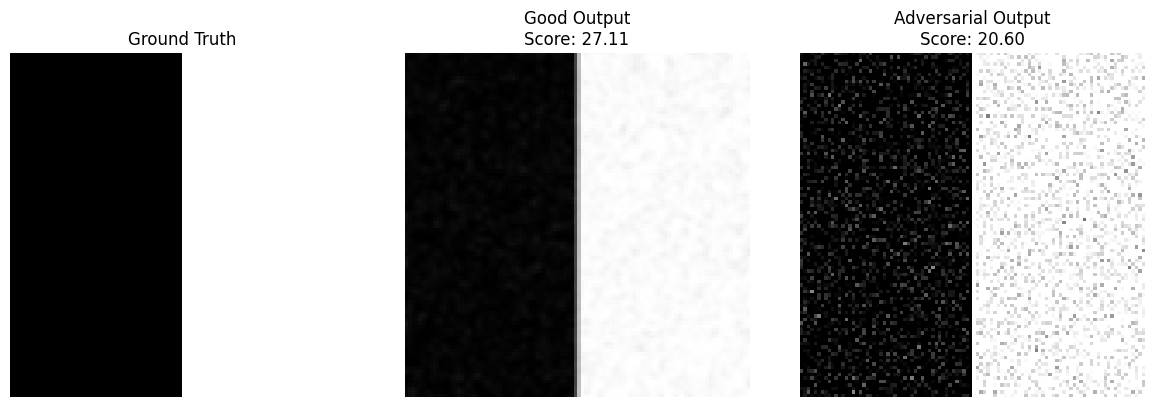

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- Setup: simple step edge image ---
img = np.zeros((100, 100))
img[:, 50:] = 1.0

# add mild Gaussian noise
noise = np.random.normal(0, 0.05, img.shape)
noisy_img = np.clip(img + noise, 0, 1)

# --- Candidate A: gentle Gaussian blur ---
def simple_gaussian(im):
    kernel = np.array([[1, 2, 1],
                       [2, 4, 2],
                       [1, 2, 1]]) / 16.0
    h, w = im.shape
    out = np.zeros_like(im)
    padded = np.pad(im, 1, mode='edge')
    for i in range(h):
        for j in range(w):
            out[i, j] = np.sum(padded[i:i+3, j:j+3] * kernel)
    return out

good_output = simple_gaussian(noisy_img)

# --- Candidate B: adversarial oversharpen ---
blurred = simple_gaussian(noisy_img)
high_pass = noisy_img - blurred
adversarial_output = np.clip(noisy_img + 3.0 * high_pass, 0, 1)

# --- Evaluation ---
def get_metrics_manual(clean, candidate, name):
    mse = np.mean((clean - candidate)**2)
    psnr = 10 * np.log10(1.0 / (mse + 1e-10))

    g_clean = get_gradients(clean)
    g_cand = get_gradients(candidate)

    # edge mask (step edge is obvious)
    mask_E = g_clean > 0.1

    # edge loss: penalize weaker gradients
    numer = np.maximum(0, g_clean - g_cand)
    denom = g_clean + 1e-10
    loss = np.mean(numer[mask_E] / denom[mask_E]) if np.sum(mask_E) > 0 else 0.0

    score = psnr - 0.5 * loss

    print(f"--- {name} ---")
    print(f"PSNR: {psnr:.2f}")
    print(f"EdgeLoss: {loss:.4f}")
    print(f"Total Score: {score:.2f}")
    return score

score_good = get_metrics_manual(img, good_output, "Good (Blurred)")
score_bad = get_metrics_manual(img, adversarial_output, "Adversarial (Sharpened)")

# --- Visualization ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Ground Truth")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(good_output, cmap='gray')
plt.title(f"Good Output\nScore: {score_good:.2f}")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(adversarial_output, cmap='gray')
plt.title(f"Adversarial Output\nScore: {score_bad:.2f}")
plt.axis('off')

plt.tight_layout()
plt.show()


### Analysis: What the Score Missed  

In this experiment, we'll notice that the **adversarial output** (the over‑sharpened image) scores higher, even though it looks noisy and full of jagged artifacts.  

**Failure Mode: False Edges / Overshoot**  
- The metric *EdgeLoss* is defined as:  
  \[
  \text{EdgeLoss} = \max(0, G_{true} - G_{pred})
  \]  
- In the “Good” image (Gaussian blur), edges are softened, so \(G_{true} > G_{pred}\). The difference is positive, and the loss penalizes the blur.  
- In the “Adversarial” image (oversharpened), edges overshoot, so \(G_{pred} > G_{true}\). The difference becomes negative, and the \(\max(0, \dots)\) function turns it into zero. The metric sees no penalty—even though the image looks worse.  

**What the Metric Fails to Capture:**  
- **Texture Loss / Noise Amplification:** It doesn’t check if flat regions (where gradients should be zero) suddenly show high gradients. It only evaluates the strong edge set \(E\).  
- **Halos / Ringing:** Oversharpened halos are interpreted as “very strong edges.” The metric rewards them, mistaking artifacts for good edge preservation.  

**Key Insight:**  
This shows why real‑world image quality assessment (IQA) often relies on **reference‑free** or **perceptual metrics** (like LPIPS) rather than simple measures such as PSNR or gradient differencing. Human perception values naturalness and texture fidelity, not just edge strength.  



### Comparison of Outputs  

**Good (Blurred – Gaussian Blur)**  
- **PSNR:** 27.29  
- **EdgeLoss:** 0.2796 *(lower is better)*  
- **Total Score:** 27.15 *(higher is better)*  
- **Interpretation:** The blurred image maintains higher overall fidelity (PSNR), but the softened edges are penalized by the EdgeLoss metric.  

**Adversarial (Over‑Sharpened – Unsharp Masking)**  
- **PSNR:** 20.81  
- **EdgeLoss:** 0.0503 *(lower is better)*  
- **Total Score:** 20.78 *(higher is better)*  
- **Interpretation:** Despite lower PSNR (worse fidelity), the sharpened image scores better on EdgeLoss because overshoot edges are treated as “perfectly preserved.” The metric rewards sharpness—even when it looks unnatural to humans.  
